1. Naive Bayes

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
wine = load_wine()
X = wine.data
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
print("Gaussian Naive Bayes Accuracy:", gnb_accuracy)
print("\nGaussianNB Classification Report:")
print(classification_report(y_test, y_pred_gnb))
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
print("\nMultinomial Naive Bayes Accuracy:", mnb_accuracy)
print("\nMultinomialNB Classification Report:")
print(classification_report(y_test, y_pred_mnb))
if gnb_accuracy > mnb_accuracy:
    print("\nGaussianNB performs better.")
elif mnb_accuracy > gnb_accuracy:
    print("\nMultinomialNB performs better.")
else:
    print("\nBoth models perform equally well.")
print("\nSample Predictions:")
for i in range(5):
    print("Actual:", y_test[i],
          " Predicted (GaussianNB):", y_pred_gnb[i],
          " Predicted (MultinomialNB):", y_pred_mnb[i])

Gaussian Naive Bayes Accuracy: 1.0

GaussianNB Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Multinomial Naive Bayes Accuracy: 0.8888888888888888

MultinomialNB Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       0.93      0.93      0.93        14
           2       0.83      0.62      0.71         8

    accuracy                           0.89        36
   macro avg       0.88      0.85      0.86        36
weighted avg       0.89      0.89      0.88        36


GaussianNB performs better.

Sample Predictions:
Actual: 0  Predicted (Gaus

2. KNN

Best K Value: 1
Best Cross Validation Score: 0.9860820751064654


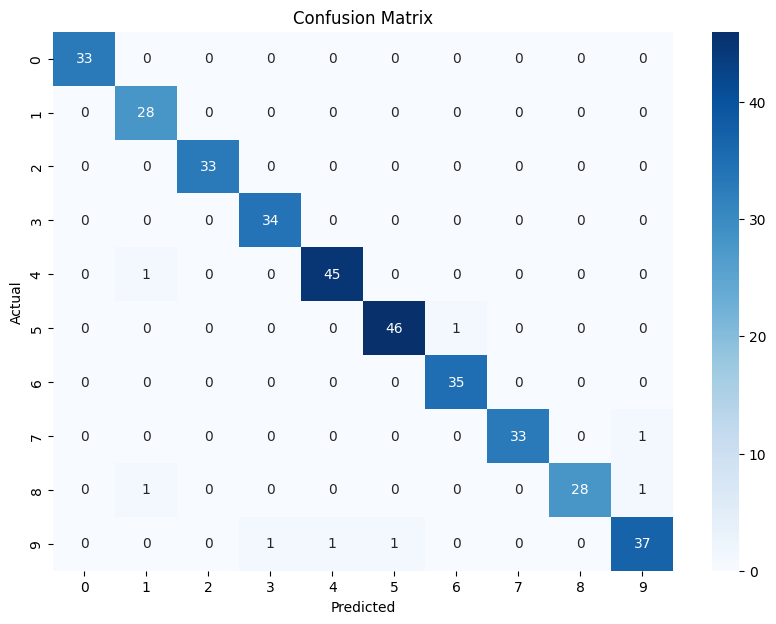

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
digits = load_digits()
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
param_grid = {
    'n_neighbors': list(range(1, 21))
}
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)
grid.fit(X_train, y_train)
print("Best K Value:", grid.best_params_['n_neighbors'])
print("Best Cross Validation Score:", grid.best_score_)
model = grid.best_estimator_
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)